# Trabalho Prático 01 — Classificação KNN (Parte 1: Implementação *From Scratch*)

**Disciplina:** GCC 128 — Inteligência Artificial  
**Instituição:** Universidade Federal de Lavras (UFLA)  
**Docentes:** Prof. Ahmed Ali Abdalla Esmin  
**Discentes:** Caio Bueno Finocchio Martins e Lana da Silva Miranda  

---


## Instalação de Pacotes

In [1]:
%pip install -q kagglehub pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



## 1. Carregamento do Conjunto de Dados (Iris Dataset)

A base de dados *Iris* é importada utilizando a biblioteca `kagglehub` e convertida temporariamente em um `DataFrame` `pandas` para validação inicial.



In [2]:
import kagglehub
import pandas as pd
from collections import Counter
from kagglehub import KaggleDatasetAdapter

file_path = "Iris.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/iris",
  file_path,
)

df.head()

C:\Users\caiof\AppData\Local\Temp\ipykernel_17576\1491832084.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


---
##2. Armazenamento dos Objetos em Estrutura de Dados

Conforme requisitado para a implementação *from scratch*, converte-se o `DataFrame` para uma lista de listas nativa do Python (`base_dados`).

Cada elemento da lista possui a seguinte estrutura: `[SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species]`.

In [3]:
base_dados = []

for index, row in df.iterrows():
    base_dados.append([row['SepalLengthCm'], row['SepalWidthCm'], row['PetalLengthCm'], row['PetalWidthCm'], row['Species']])

print(f"Quantidade total de amostras: {len(base_dados)}")
print(f"Exemplo: {base_dados[0]}")

Quantidade total de amostras: 150
Exemplo: [5.1, 3.5, 1.4, 0.2, 'Iris-setosa']


**Separação entre treino e teste:** a base foi dividida em 70% para treino e 30% para teste, mantendo a proporção das classes. Isso permite avaliar o KNN com amostras que não foram utilizadas como referência durante a classificação.


In [4]:
from sklearn.model_selection import train_test_split

base_treino, base_teste = train_test_split(
    base_dados,
    test_size=0.30,
    random_state=42,
    stratify=[dado[-1] for dado in base_dados],
)

print(f"Amostras de treino: {len(base_treino)}")
print(f"Amostras de teste: {len(base_teste)}")


Amostras de treino: 105
Amostras de teste: 45


---
## 3. Algoritmo K-Nearest Neighbors (KNN) - Implementação manual

### 3.1. Métrica de Distância Euclidiana

A distância entre o vetor de entrada $x$ e uma amostra da base $y$ é dada por:

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

em que $n = 4$ corresponde ao número de atributos de entrada.

In [5]:
def distancia_euclidiana(entrada, dado):
  distancia = 0
  for i in range(len(entrada)):
    distancia += (entrada[i] - dado[i])**2
  return distancia**0.5

### 3.2. Busca dos $k$ Vizinhos Mais Próximos

A função knn percorre as amostras da base de treino, calcula a distância euclidiana entre seus atributos e a entrada e ordena os resultados para selecionar os $k$ vizinhos mais próximos.

In [6]:
def knn(entrada, k, base_treino):
  distancias = []
  for dado in base_treino:
      atributos = dado[:-1]
      especie = dado[-1]

      distancia = distancia_euclidiana(entrada, atributos)
      distancias.append((distancia, especie))

  distancias.sort(key=lambda item: item[0])

  return distancias[:k] # retorna só os k primeiro elementos da lista

### 3.3. Apuração da Votação e Decisão da Classe

A função classificar contabiliza as classes presentes entre os $k$ vizinhos e retorna a classe com maior frequência. Em caso de empate, é escolhida a classe do vizinho mais próximo.


In [7]:
def classificar(vizinhos): # recebe lista de (distancia, especie)
    especies = [especie for _, especie in vizinhos]
    contagens = Counter(especies) # conta repeticoes dos elementos na lista

    maior_contagem = max(contagens.values())

    classes_maxima_contagem = {
        especie
        for especie, quantidade in contagens.items() # Para considerar empates
        if quantidade == maior_contagem
    }

    # Como os vizinhos já estão ordenados pela distância,
    # a primeira classe empatada encontrada possui o vizinho mais próximo.
    for _, especie in vizinhos:
        if especie in classes_maxima_contagem:
            return especie

A função `classificar_amostra` reúne as etapas do KNN, obtendo os vizinhos mais próximos e utilizando-os para determinar a classe prevista da amostra.


In [8]:
def classificar_amostra(entrada, k, base_treino):
    vizinhos = knn(entrada, k, base_treino)
    classe_resultado = classificar(vizinhos)

    return classe_resultado, vizinhos

A função `obter_resultados` classifica todas as amostras da base de teste e retorna as classes reais e previstas, que serão utilizadas na avaliação do classificador.

In [9]:
def obter_resultados(base_treino, base_teste, k):
    classes_reais = []
    classes_resultados = []

    for dado in base_teste:
        entrada = dado[:-1]
        classe_real = dado[-1] #último elemento do vetor

        classe_resultado, _ = classificar_amostra(
            entrada,
            k,
            base_treino,
        )

        classes_reais.append(classe_real)
        classes_resultados.append(classe_resultado)

    return classes_reais, classes_resultados


A função `imprimir_classificacao` é responsável apenas por exibir a quantidade de votos recebidos por cada classe e a classificação final obtida para um k específico.


In [10]:
def imprimir_classificacao(vizinhos, classe_resultado):

    contagens = Counter(especie for _, especie in vizinhos)

    for especie, quantidade in sorted(contagens.items()):
        print(f"{especie}: {quantidade}")

    print(f"Resposta final: {classe_resultado}")

### 3.4. Avaliação do Classificador



A matriz de confusão compara as classes reais das amostras com as classes previstas pelo KNN, permitindo visualizar tanto as classificações corretas quanto os erros cometidos pelo classificador. Ela será usada para avaliar o classificador na próxima seção.

In [11]:
def gerar_matriz_confusao(classes_reais, classes_resultados):
    classes = sorted(set(classes_reais))

    matriz = [
        [0 for _ in classes]
        for _ in classes
    ]

    for real, resultado in zip(classes_reais, classes_resultados):
        linha = classes.index(real)
        coluna = classes.index(resultado)

        matriz[linha][coluna] += 1

    matriz_df = pd.DataFrame(
        matriz,
        index=classes,
        columns=classes
    )

    return matriz_df

O bloco abaixo é responsável pela visualização das matrizes de confusão, transformando os dados gerados em `gerar_matriz_confusao` em gráficos.

A função `plotar_matriz_confusao` desenha uma matriz individual, enquanto `plotar_grade_matrizes` organiza as matrizes dos diferentes valores de \(k\) em uma grade 2×2. Essas funções serão chamadas posteriormente na seção de avaliação do classificador, após a obtenção das classes reais e previstas.

In [12]:
# @title
import matplotlib.pyplot as plt

def plotar_matriz_confusao(matriz_df, k, ax, vmax):
    imagem = ax.imshow(
        matriz_df.values,
        cmap="YlGnBu",
        vmin=0,
        vmax=vmax
    )

    ax.set_xticks(range(len(matriz_df.columns)))
    ax.set_yticks(range(len(matriz_df.index)))

    ax.set_xticklabels(matriz_df.columns, fontsize=8)
    ax.set_yticklabels(matriz_df.index, fontsize=8)

    ax.set_xlabel("Classe prevista", fontsize=9)
    ax.set_ylabel("Classe real", fontsize=9)
    ax.set_title(f"k = {k}", fontsize=11)

    for i in range(len(matriz_df.index)):
        for j in range(len(matriz_df.columns)):
            ax.text(
                j,
                i,
                matriz_df.iloc[i, j],
                ha="center",
                va="center",
                fontsize=9
            )

    return imagem

def plotar_grade_matrizes(matrizes):
  vmax = max(
      matriz.values.max()
      for matriz in matrizes.values()
  )
  fig, axes = plt.subplots(
      2,
      2,
      figsize=(10, 8)
  )
  axes = axes.flatten()
  for ax, k in zip(axes, valores_k):
      imagem = plotar_matriz_confusao(
          matrizes[k],
          k,
          ax,
          vmax
      )
  fig.suptitle(
      "Matrizes de Confusão do KNN",
      fontsize=15,
      y=0.98
  )
  fig.subplots_adjust(
      wspace=0.55,
      hspace=0.45,
      right=0.87,
      top=0.90
  )
  cbar_ax = fig.add_axes([0.90, 0.18, 0.025, 0.64])
  fig.colorbar(
      imagem,
      cax=cbar_ax,
      label="Quantidade de amostras"
  )

As funções `calcular_acuracia` e `calcular_precisao_revocacao` calculam as métricas de avaliação do classificador.

In [13]:
def calcular_acuracia(matriz_df):
    acertos = matriz_df.values.diagonal().sum()
    total = matriz_df.values.sum()

    return acertos / total

In [14]:
def calcular_precisao_revocacao(matriz_df):
    resultados = []

    for classe in matriz_df.index:
        vp = matriz_df.loc[classe, classe]      # Verdadeiro positivo = diagonal
        fp = matriz_df[classe].sum() - vp       # Falso positivo = coluna - vp
        fn = matriz_df.loc[classe].sum() - vp   # Falso negativo = linha - vp

        precisao = vp / (vp + fp) if (vp + fp) > 0 else 0
        revocacao = vp / (vp + fn) if (vp + fn) > 0 else 0

        resultados.append([
            classe,
            precisao,
            revocacao
        ])

    return pd.DataFrame(
        resultados,
        columns=["Classe", "Precisão", "Revocação"]
    )


Import necessário para medir o tempo de execução dos algoritmos. A implementação dos classificadores já vai calcular a métrica para avaliação de desempenho, que será usada na seção 5.1.

In [15]:
import time

Executa a avaliação para k = \{1,3,5,7\}, gerando a matriz de confusão e as métricas de cada configuração.

In [16]:
valores_k = (1, 3, 5, 7)

matrizes = {}
tempo = {}

for k in valores_k:
    inicio = time.perf_counter()

    classes_reais, classes_resultados = obter_resultados(
        base_treino,
        base_teste,
        k
    )

    fim = time.perf_counter()
    tempo[k] = fim - inicio

    matriz_df = gerar_matriz_confusao(
        classes_reais,
        classes_resultados
    )

    matrizes[k] = matriz_df

    acuracia = calcular_acuracia(matriz_df)
    metricas_df = calcular_precisao_revocacao(matriz_df)

    print(f"k = {k}")
    print(f"Acurácia: {acuracia:.2%}")
    display(
        metricas_df.style.format({
            "Precisão": "{:.2%}",
            "Revocação": "{:.2%}"
        })
    )
    print(f"Tempo de execução: {tempo[k]:.5f} segundos")
    print('\n')


k = 1
Acurácia: 93.33%


,Classe,Precisão,Revocação
0,Iris-setosa,100.00%,100.00%
1,Iris-versicolor,83.33%,100.00%
2,Iris-virginica,100.00%,80.00%


Tempo de execução: 0.00462 segundos


k = 3
Acurácia: 95.56%


,Classe,Precisão,Revocação
0,Iris-setosa,100.00%,100.00%
1,Iris-versicolor,88.24%,100.00%
2,Iris-virginica,100.00%,86.67%


Tempo de execução: 0.00539 segundos


k = 5
Acurácia: 97.78%


,Classe,Precisão,Revocação
0,Iris-setosa,100.00%,100.00%
1,Iris-versicolor,93.75%,100.00%
2,Iris-virginica,100.00%,93.33%


Tempo de execução: 0.00530 segundos


k = 7
Acurácia: 95.56%


,Classe,Precisão,Revocação
0,Iris-setosa,100.00%,100.00%
1,Iris-versicolor,88.24%,100.00%
2,Iris-virginica,100.00%,86.67%


Tempo de execução: 0.00442 segundos




Exibe as matrizes de confusão dos quatro valores de \(k\).

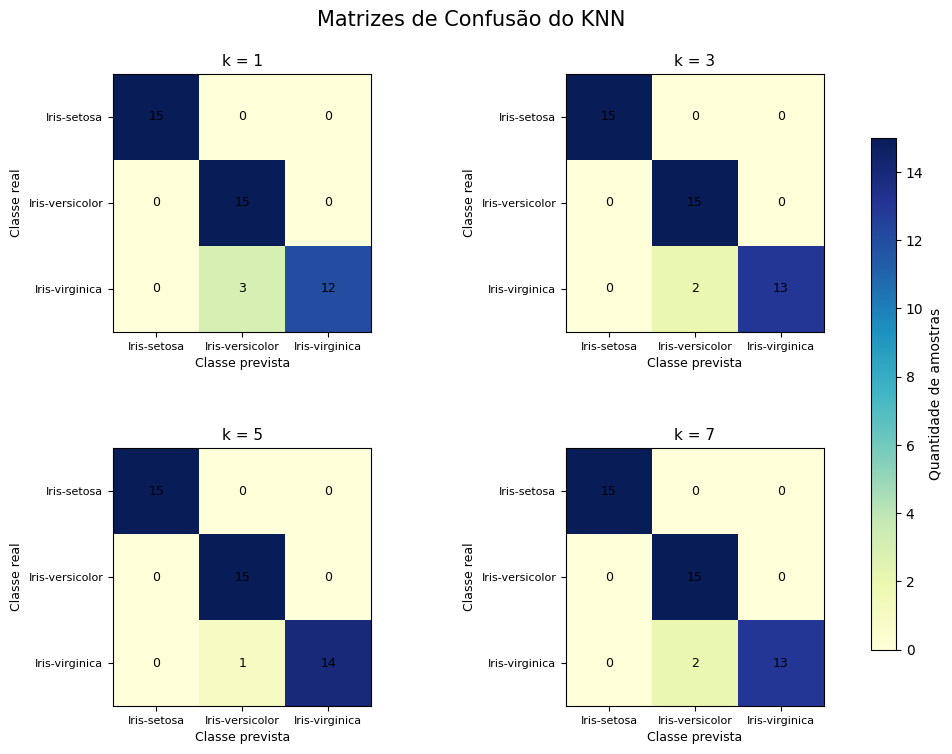

In [17]:
plotar_grade_matrizes(matrizes)
plt.show()

### 3.5. Teste Manual do Classificador

Por fim, é possível informar manualmente os quatro atributos de uma nova amostra para que o KNN realize sua classificação utilizando a base de treino.


In [18]:
# entrada = []
# entrada.append(float(input("Digite o comprimento da sépala: ")))
# entrada.append(float(input("Digite a largura da sépala: ")))
# entrada.append(float(input("Digite o comprimento da pétala: ")))
# entrada.append(float(input("Digite a largura da pétala: ")))
# k = (int(input("Digite o valor do k: ")))

# classe_predita, vizinhos = classificar_amostra(
#     entrada,
#     k,
#     base_treino,
# )

# print(f"\nEntrada: {entrada}")
# print(f"Vizinhos: {vizinhos}\n")
# imprimir_classificacao(vizinhos, classe_predita)

## 4. Nearest Neighbors com Scikit-learn
### 4.1 Implementação do Classificador

Importa da biblioteca Scikit-learn a classe `KNeighborsClassifier`, que fornece uma implementação pronta do algoritmo KNN para problemas de classificação.

In [19]:
from sklearn.neighbors import KNeighborsClassifier

Na função `classificar_sklearn`, os atributos e as espécies são separados para treino e teste, o classificador é ajustado com a base de treino e, em seguida, são geradas as previsões para a base de teste.

In [20]:
def classificar_sklearn(base_treino, base_teste, k):
    atributos_treino = [dado[:-1] for dado in base_treino]
    especies_treino = [dado[-1] for dado in base_treino]

    atributos_teste = [dado[:-1] for dado in base_teste]
    especies_teste = [dado[-1] for dado in base_teste]

    classificador = KNeighborsClassifier(n_neighbors=k)

    classificador.fit(atributos_treino, especies_treino)

    classes_resultados = classificador.predict(atributos_teste)

    print(f"Tempo de execução: {fim - inicio:.5f} segundos")

    return especies_teste, classes_resultados

### 4.2. Avaliação do Classificador

Para cada valor de k, são obtidas as classes reais e previstas pelo classificador do Scikit-learn e, a partir delas, é gerada a matriz de confusão correspondente. As mesmas funções utilizadas na implementação manual são reaproveitadas para calcular acurácia, precisão e revocação a partir das matrizes de confusão, permitindo uma comparação direta entre os classificadores.

Além disso, são registrados o tempo de execução e o uso de memória para cada valor de k.

In [21]:
valores_k = (1, 3, 5, 7)
tempo_sklearn = {}
matrizes_sklearn = {}

for k in valores_k:
    inicio = time.perf_counter()

    classes_reais, classes_resultados = classificar_sklearn(
        base_treino,
        base_teste,
        k
    )

    fim = time.perf_counter()
    tempo_sklearn[k] = fim - inicio

    matriz_df = gerar_matriz_confusao(
        classes_reais,
        classes_resultados
    )

    matrizes_sklearn[k] = matriz_df

    acuracia = calcular_acuracia(matriz_df)
    metricas_df = calcular_precisao_revocacao(matriz_df)

    print(f"k = {k}")
    print(f"Acurácia: {acuracia:.2%}")

    display(
        metricas_df.style.format({
            "Precisão": "{:.2%}",
            "Revocação": "{:.2%}"
        })
    )
    print(f"Tempo: {tempo_sklearn[k]:.5f} segundos")
    print('\n')

Tempo de execução: -0.98427 segundos
k = 1
Acurácia: 93.33%


,Classe,Precisão,Revocação
0,Iris-setosa,100.00%,100.00%
1,Iris-versicolor,83.33%,100.00%
2,Iris-virginica,100.00%,80.00%


Tempo: 0.00509 segundos


Tempo de execução: -0.00452 segundos
k = 3
Acurácia: 95.56%


,Classe,Precisão,Revocação
0,Iris-setosa,100.00%,100.00%
1,Iris-versicolor,88.24%,100.00%
2,Iris-virginica,100.00%,86.67%


Tempo: 0.00397 segundos


Tempo de execução: -0.00518 segundos
k = 5
Acurácia: 97.78%


,Classe,Precisão,Revocação
0,Iris-setosa,100.00%,100.00%
1,Iris-versicolor,93.75%,100.00%
2,Iris-virginica,100.00%,93.33%


Tempo: 0.00311 segundos


Tempo de execução: -0.00399 segundos
k = 7
Acurácia: 95.56%


,Classe,Precisão,Revocação
0,Iris-setosa,100.00%,100.00%
1,Iris-versicolor,88.24%,100.00%
2,Iris-virginica,100.00%,86.67%


Tempo: 0.00316 segundos




Exibe as matrizes de confusão dos diferentes valores de k são exibidas.

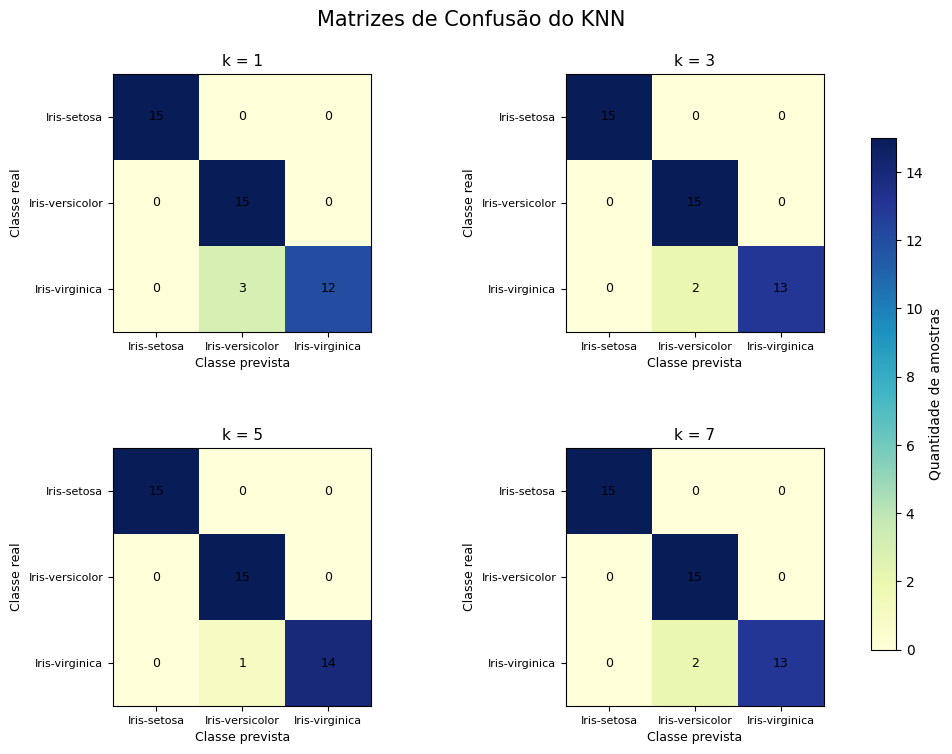

In [22]:
plotar_grade_matrizes(matrizes_sklearn)

## 5. Comparação das Implementações


### 5.1 Comparação das métricas

As métricas obtidas pelas duas implementações são comparadas para os mesmos valores de k. Para precisão e revocação, é utilizada a média dos resultados das três classes.


In [23]:
comparacao = []

for k in valores_k:
    matriz_manual = matrizes[k]
    matriz_sklearn = matrizes_sklearn[k]

    # Manual
    acuracia_manual = calcular_acuracia(matriz_manual)
    metricas_manual = calcular_precisao_revocacao(matriz_manual)

    precisao_manual = metricas_manual["Precisão"].mean()
    revocacao_manual = metricas_manual["Revocação"].mean()

    comparacao.append([
        k,
        "Manual",
        acuracia_manual,
        precisao_manual,
        revocacao_manual,
        tempo[k]
    ])

    # Scikit-learn
    acuracia_sklearn = calcular_acuracia(matriz_sklearn)
    metricas_sklearn = calcular_precisao_revocacao(matriz_sklearn)

    precisao_sklearn = metricas_sklearn["Precisão"].mean()
    revocacao_sklearn = metricas_sklearn["Revocação"].mean()

    comparacao.append([
        k,
        "Scikit-learn",
        acuracia_sklearn,
        precisao_sklearn,
        revocacao_sklearn,
        tempo_sklearn[k]
    ])

comparacao_df = pd.DataFrame(
    comparacao,
    columns=[
        "k",
        "Implementação",
        "Acurácia",
        "Precisão média",
        "Revocação média",
        "Tempo (s)"
    ]
)

display(
    comparacao_df.style.format({
        "Acurácia": "{:.2%}",
        "Precisão média": "{:.2%}",
        "Revocação média": "{:.2%}",
        "Tempo (s)": "{:.5f}"
    })
)

,k,Implementação,Acurácia,Precisão média,Revocação média,Tempo (s)
0,1,Manual,93.33%,94.44%,93.33%,0.00462
1,1,Scikit-learn,93.33%,94.44%,93.33%,0.00509
2,3,Manual,95.56%,96.08%,95.56%,0.00539
3,3,Scikit-learn,95.56%,96.08%,95.56%,0.00397
4,5,Manual,97.78%,97.92%,97.78%,0.00530
5,5,Scikit-learn,97.78%,97.92%,97.78%,0.00311
6,7,Manual,95.56%,96.08%,95.56%,0.00442
7,7,Scikit-learn,95.56%,96.08%,95.56%,0.00316


### 5.2. Comparação das Matrizes de Confusão

As matrizes de confusão são comparadas para verificar se as duas implementações produziram os mesmos resultados de classificação.

In [24]:
comparacao_matrizes = []

for k in valores_k:
    iguais = matrizes[k].equals(matrizes_sklearn[k])

    comparacao_matrizes.append([
        k,
        "Sim" if iguais else "Não"
    ])

comparacao_matrizes_df = pd.DataFrame(
    comparacao_matrizes,
    columns=["k", "Matrizes iguais"]
)

display(comparacao_matrizes_df)

,k,Matrizes iguais
0,1,Sim
1,3,Sim
2,5,Sim
3,7,Sim


### 5.3 Análise dos Resultados

As implementações manual e do Scikit-learn produziram as mesmas classificações e matrizes de confusão para todos os valores de k. Esse resultado é esperado, pois ambas utilizaram a mesma divisão dos dados, distância euclidiana e votação uniforme entre os vizinhos, que também são os padrões do `KNeighborsClassifier`.

O melhor resultado ocorreu com k = 5, com acurácia de 97,78%, precisão média de 97,92% e revocação média de 97,78%. Enquanto a acurácia mostra a proporção total de acertos, a precisão indica a confiabilidade das previsões de cada classe e a revocação mede quantas amostras reais de cada classe foram identificadas corretamente. Os valores altos e próximos entre si indicam um desempenho equilibrado, sem concentração relevante de erros em uma classe específica.

Os tempos de execução podem variar entre rodadas, pois a base Iris é pequena e as diferenças medidas são muito reduzidas. Ainda assim, o Scikit-learn tende a ser mais eficiente por ser uma implementação otimizada, enquanto a versão manual é importante para explicitar cada etapa do algoritmo. Em conjuntos maiores ou com outras configurações — como pesos por distância, outra métrica ou empates na votação — os resultados podem deixar de ser idênticos.